#Import libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

#Data Collection

In [ ]:
df=pd.read_csv('/content/Flights_2022_9.csv', engine='python', on_bad_lines='skip')

In [ ]:
df.head()

,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Marketing_Airline_Network,Operated_or_Branded_Code_Share_Partners,DOT_ID_Marketing_Airline,IATA_Code_Marketing_Airline,...,Div5Airport,Div5AirportID,Div5AirportSeqID,Div5WheelsOn,Div5TotalGTime,Div5LongestGTime,Div5WheelsOff,Div5TailNum,Duplicate,Unnamed: 119
0,2022,3,9,2,5,2022-09-02,AA,AA_CODESHARE,19805,AA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN
1,2022,3,9,3,6,2022-09-03,AA,AA_CODESHARE,19805,AA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN
2,2022,3,9,4,7,2022-09-04,AA,AA_CODESHARE,19805,AA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN
3,2022,3,9,5,1,2022-09-05,AA,AA_CODESHARE,19805,AA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN
4,2022,3,9,6,2,2022-09-06,AA,AA_CODESHARE,19805,AA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN


#EDA

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 580391 entries, 0 to 580390
Columns: 120 entries, Year to Unnamed: 119
dtypes: float64(72), int64(23), object(25)
memory usage: 531.4+ MB


In [ ]:
df.describe()

,Year,Quarter,Month,DayofMonth,DayOfWeek,DOT_ID_Marketing_Airline,Flight_Number_Marketing_Airline,DOT_ID_Originally_Scheduled_Code_Share_Airline,Flight_Num_Originally_Scheduled_Code_Share_Airline,DOT_ID_Operating_Airline,...,Div4TailNum,Div5Airport,Div5AirportID,Div5AirportSeqID,Div5WheelsOn,Div5TotalGTime,Div5LongestGTime,Div5WheelsOff,Div5TailNum,Unnamed: 119
count,580391.0,580391.0,580391.0,580391.000000,580391.000000,580391.000000,580391.000000,96.000000,96.000000,580391.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,2022.0,3.0,9.0,15.569444,4.002789,19824.723435,2458.567883,20331.854167,4973.020833,19972.406016,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.0,0.0,0.0,8.681144,1.938201,281.060850,1701.645812,125.094236,763.214545,378.358321,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,2022.0,3.0,9.0,1.000000,1.000000,19393.000000,1.000000,20046.000000,3524.000000,19393.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,2022.0,3.0,9.0,8.000000,2.000000,19790.000000,1067.000000,20304.000000,4352.250000,19790.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,2022.0,3.0,9.0,16.000000,4.000000,19805.000000,2133.000000,20397.000000,5542.000000,19930.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,2022.0,3.0,9.0,23.000000,6.000000,19977.000000,3703.000000,20397.000000,5577.000000,20368.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,2022.0,3.0,9.0,30.000000,7.000000,20436.000000,9648.000000,20445.000000,6119.000000,20500.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.isnull().sum()

,0
Year,0
Quarter,0
Month,0
DayofMonth,0
DayOfWeek,0
...,...
Div5LongestGTime,580391
Div5WheelsOff,580391
Div5TailNum,580391
Duplicate,0


In [ ]:
print ('Dataframe Info:')
df.info()

Dataframe Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 580391 entries, 0 to 580390
Columns: 120 entries, Year to Unnamed: 119
dtypes: float64(72), int64(23), object(25)
memory usage: 531.4+ MB


In [ ]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Marketing_Airline_Network,Operated_or_Branded_Code_Share_Partners,DOT_ID_Marketing_Airline,IATA_Code_Marketing_Airline,...,Div5Airport,Div5AirportID,Div5AirportSeqID,Div5WheelsOn,Div5TotalGTime,Div5LongestGTime,Div5WheelsOff,Div5TailNum,Duplicate,Unnamed: 119


#Preprocessing

In [ ]:
le=LabelEncoder()
df['Marketing_Airline_Network_Encoded']=le.fit_transform(df['Marketing_Airline_Network'])

In [ ]:
# Create the 'is_delayed' target variable based on ArrDelayMinutes
df['is_delayed'] = (df['ArrDelayMinutes'] > 15).astype(int)

#Scalling

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder

df = pd.read_csv('/content/Flights_2022_9.csv', engine='python', on_bad_lines='skip')

le = LabelEncoder()
if 'Marketing_Airline_Network' in df.columns and not df['Marketing_Airline_Network'].isnull().all():
    df['Marketing_Airline_Network_Encoded'] = le.fit_transform(df['Marketing_Airline_Network'].astype(str))

if 'ArrDelayMinutes' in df.columns:
    df['ArrDelayMinutes'] = pd.to_numeric(df['ArrDelayMinutes'], errors='coerce')
    df['is_delayed'] = (df['ArrDelayMinutes'].fillna(0) > 15).astype(int)
else:
    raise ValueError("Cannot create 'is_delayed' target as 'ArrDelayMinutes' column is missing.")

scaler = StandardScaler()

x = df.drop(columns=['is_delayed', 'ArrDelayMinutes'], errors='ignore')

non_numeric_cols = x.select_dtypes(include=['object']).columns
x = x.drop(columns=non_numeric_cols)

x = x.dropna(axis=1, how='all')

for col in x.columns:
    if pd.api.types.is_numeric_dtype(x[col]):
        x[col] = x[col].fillna(0)

if x.empty or x.shape[1] == 0:
    raise ValueError("DataFrame 'x' is empty or has no features after preprocessing, cannot perform scaling.")

y = df['is_delayed']

if y.empty:
    raise ValueError("Target variable 'y' is empty after preprocessing.")

x_scaled = scaler.fit_transform(x)

#Train Test Split

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=42)

#Data Visualization

### Correlation Heatmap

Let's visualize the correlation matrix of the numerical features in the dataset. This can help identify highly correlated features which might be useful for feature selection or understanding multicollinearity.

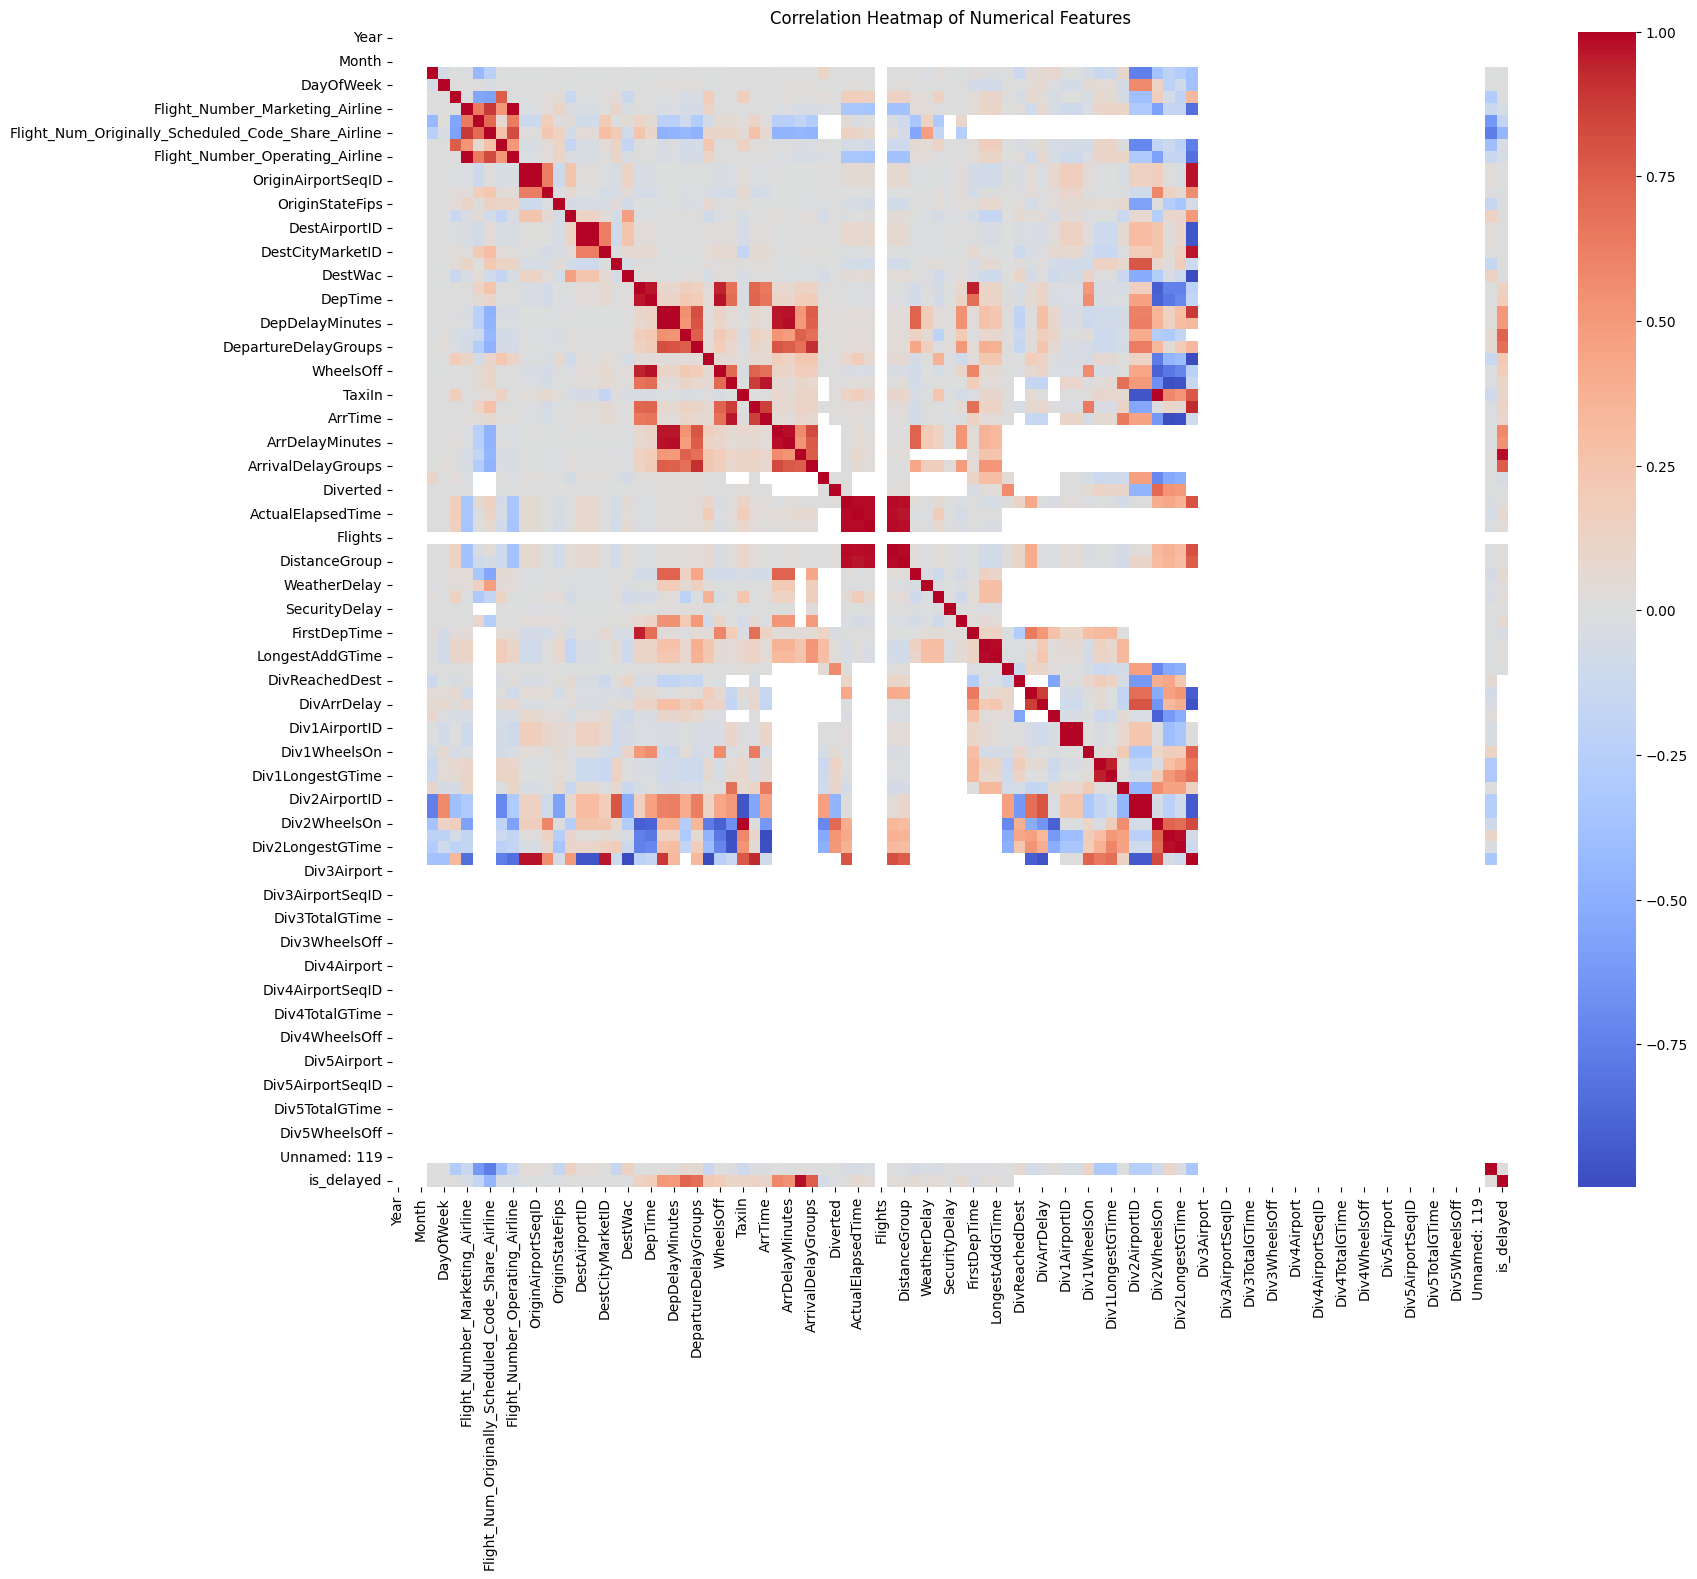

In [ ]:
plt.figure(figsize=(18, 15))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

### Pairplot of Selected Numerical Features

To further explore the relationships between numerical features, let's create a pairplot. Due to the large number of numerical columns, a subset of potentially interesting or relevant features will be selected for this visualization.

<Figure size 1200x1000 with 0 Axes>

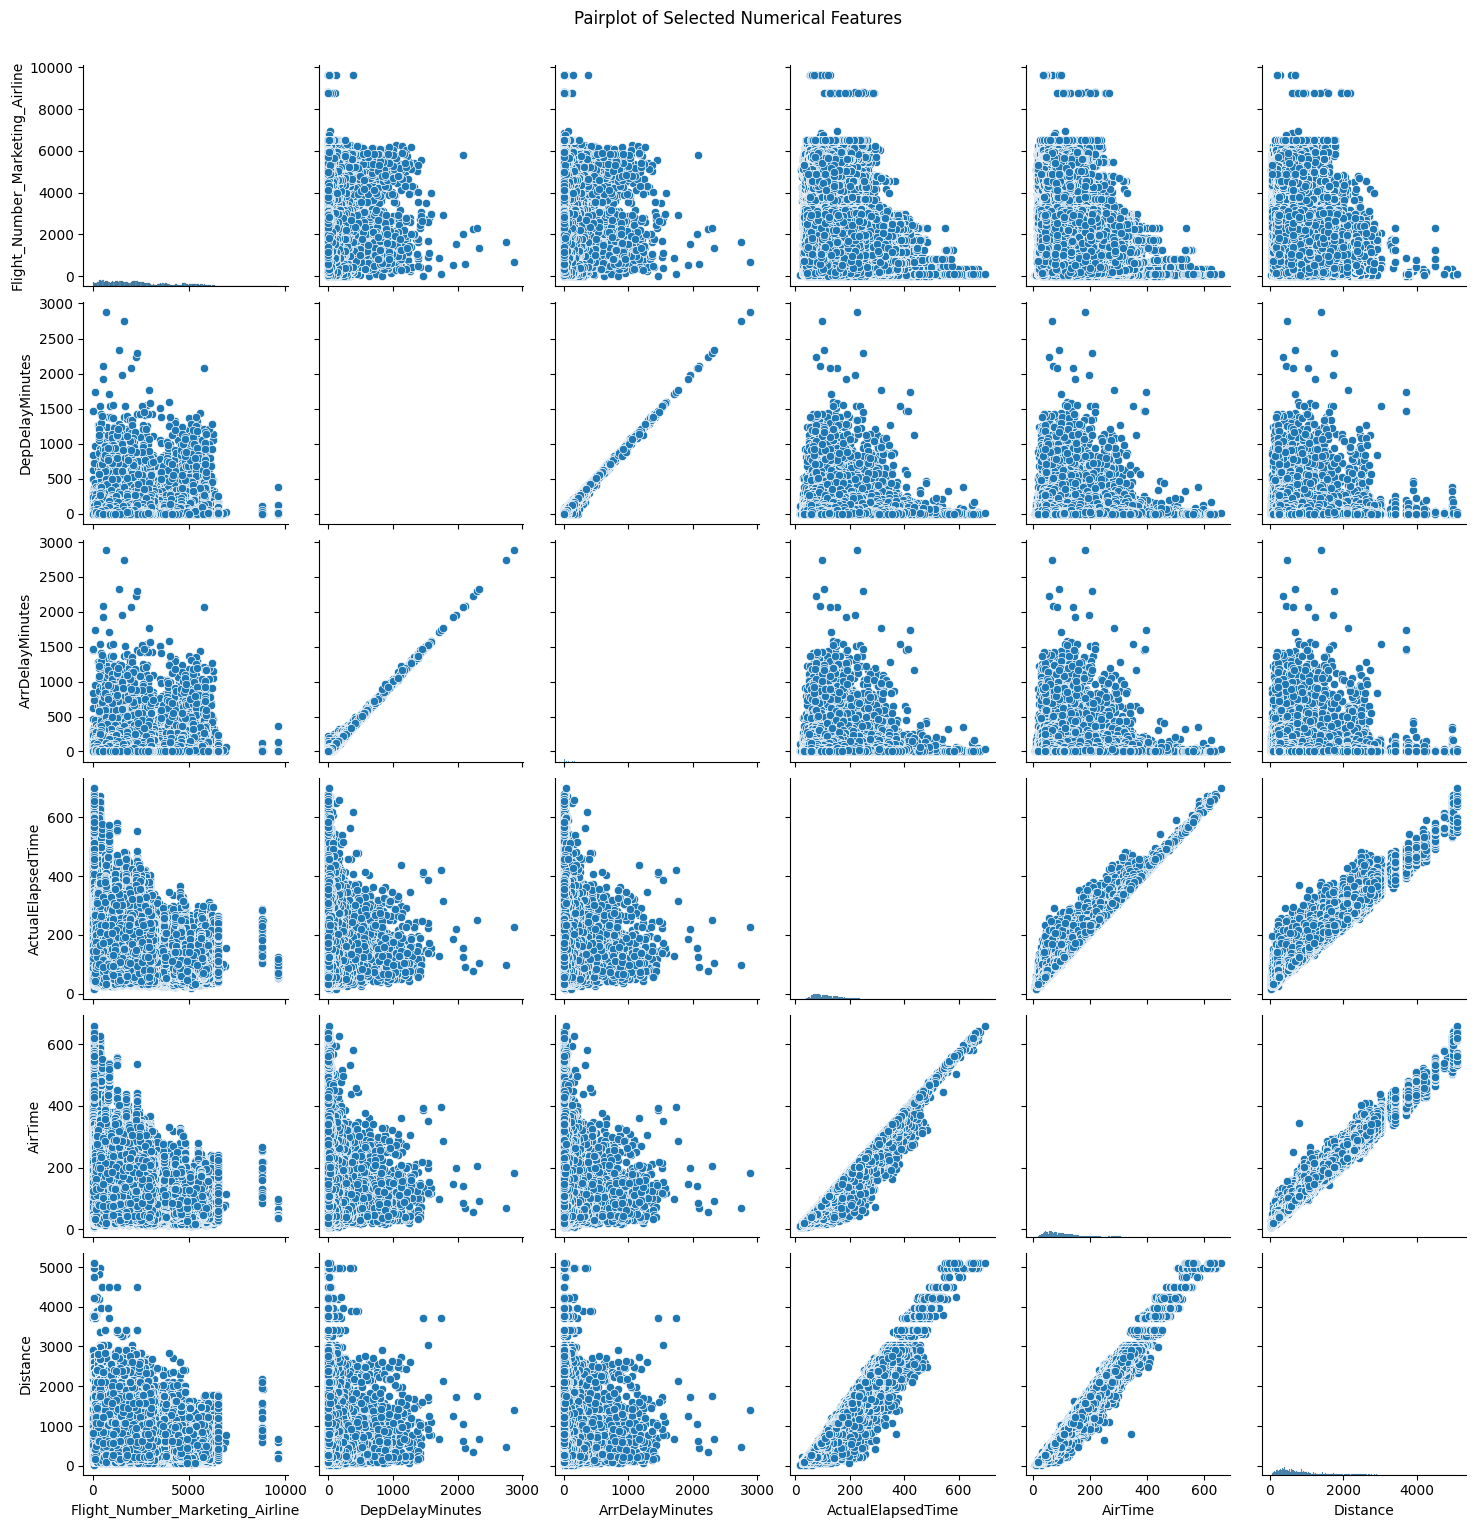

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Reload df and perform appropriate cleaning to ensure it's not empty
# This step is added here to make the current cell executable and demonstrate the pairplot,
# but ideally, the data loading and cleaning should be corrected earlier in the notebook.
df = pd.read_csv('/content/Flights_2022_9.csv', engine='python', on_bad_lines='skip')

# Drop columns with more than 70% missing values (adjust threshold as needed)
threshold = 0.7 * len(df)
df = df.dropna(axis=1, thresh=threshold)

# Drop rows where critical columns (e.g., for plotting) have NaNs, if necessary.
# For pairplot, we often want complete data for the selected columns.
df = df.dropna(subset=[
    'Flight_Number_Marketing_Airline',
    'DepDelayMinutes',
    'ArrDelayMinutes',
    'ActualElapsedTime',
    'AirTime',
    'Distance'
])

numerical_cols = df.select_dtypes(include=[np.number]).columns

# Select a subset of numerical columns for pairplot to avoid overcrowding
# You might want to adjust this list based on your specific interests
selected_numerical_cols = [
    'Flight_Number_Marketing_Airline',
    'DepDelayMinutes',
    'ArrDelayMinutes',
    'ActualElapsedTime',
    'AirTime',
    'Distance'
]

# Filter out columns that do not exist in the DataFrame
selected_numerical_cols = [col for col in selected_numerical_cols if col in numerical_cols]

if not selected_numerical_cols:
    print("No selected numerical columns found in the DataFrame for pairplot.")
elif df.empty:
    print("DataFrame is empty after cleaning, cannot create pairplot.")
else:
    plt.figure(figsize=(12,10))
    sns.pairplot(df[selected_numerical_cols])
    plt.suptitle('Pairplot of Selected Numerical Features', y=1.02) # Adjust suptitle position
    plt.show()


### Bar Plots for Categorical Features

Let's create bar plots to visualize the distribution of flights based on categorical features like `Marketing_Airline_Network` and `DayOfWeek`. This can help in understanding the frequency and patterns associated with these categories.

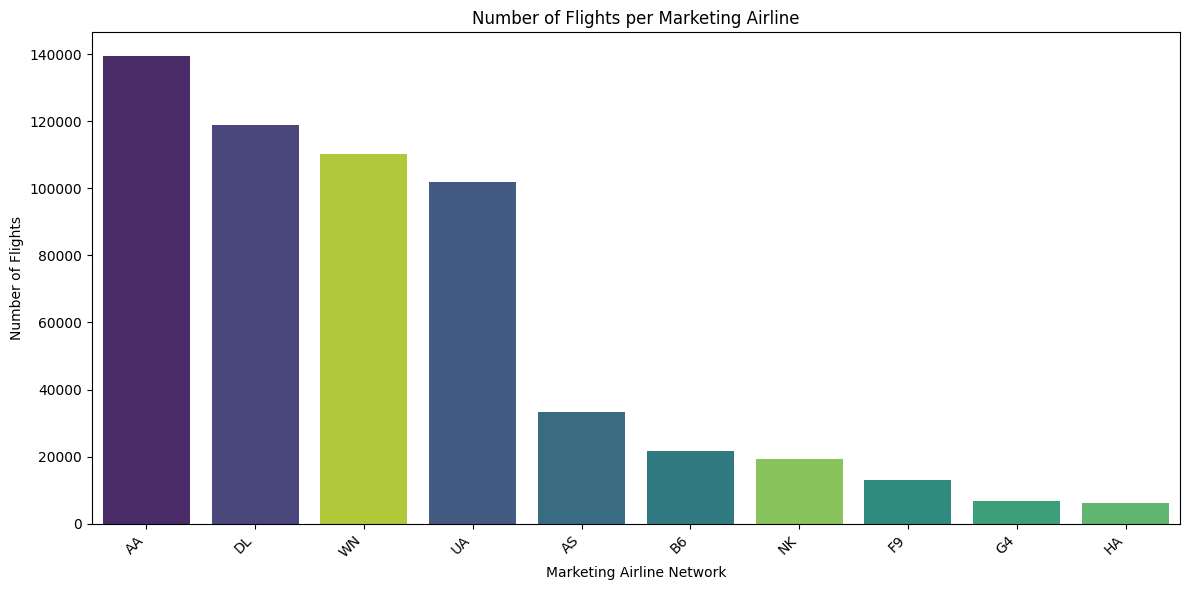

In [ ]:
# Bar plot for Marketing_Airline_Network
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Marketing_Airline_Network', hue='Marketing_Airline_Network', order=df['Marketing_Airline_Network'].value_counts().index, palette='viridis', legend=False)
plt.title('Number of Flights per Marketing Airline')
plt.xlabel('Marketing Airline Network')
plt.ylabel('Number of Flights')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

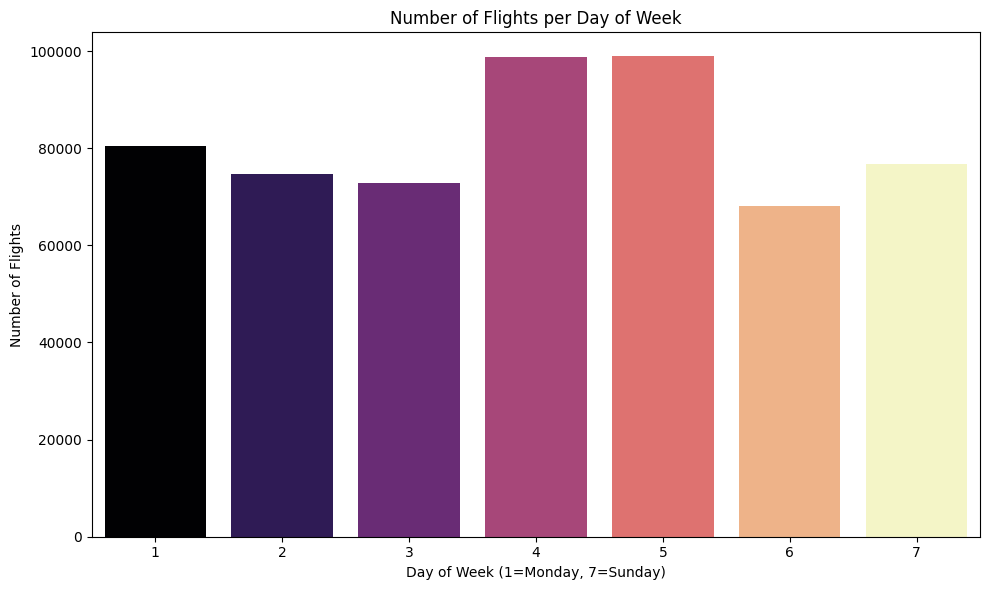

In [ ]:
# Bar plot for DayOfWeek
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='DayOfWeek', hue='DayOfWeek', palette='magma', legend=False)
plt.title('Number of Flights per Day of Week')
plt.xlabel('Day of Week (1=Monday, 7=Sunday)')
plt.ylabel('Number of Flights')
plt.tight_layout()
plt.show()

### Scatter Plot of Scheduled Departure Time vs. Scheduled Arrival Time, Colored by Arrival Delay

Let's explore the relationship between the scheduled departure and arrival times. We'll color the points based on `ArrDel15` to identify if delays are more common during specific timeframes, which could be useful for identifying peak congestion periods or operational challenges.

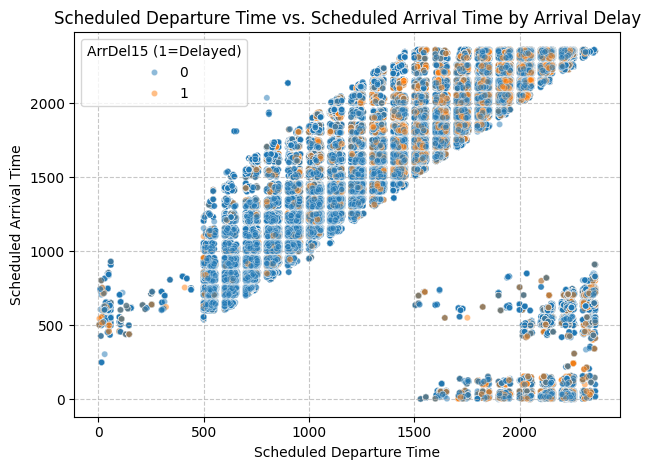

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define df_classification for plotting
df_classification = df.copy()
# Drop rows where 'ArrDel15' is NaN, as it's used for hue in the plot
df_classification = df_classification.dropna(subset=['ArrDel15'])
# Convert 'ArrDel15' to integer type for better categorization in hue
df_classification['ArrDel15'] = df_classification['ArrDel15'].astype(int)

sns.scatterplot(data=df_classification, x='CRSDepTime', y='CRSArrTime', hue='ArrDel15', alpha=0.5, s=20)
plt.title('Scheduled Departure Time vs. Scheduled Arrival Time by Arrival Delay')
plt.xlabel('Scheduled Departure Time')
plt.ylabel('Scheduled Arrival Time')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='ArrDel15 (1=Delayed)')
plt.tight_layout()
plt.show()

### Logistic Regression Model

Let's build a Logistic Regression model to classify flight delays. We will train the model using the preprocessed training data (`x_train`, `y_train`) and then make predictions on the test set (`x_test`).

In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)

# Train the model
log_reg_model.fit(x_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [ ]:
# Make predictions on the test set
y_pred_log_reg = log_reg_model.predict(x_test)

print("Predictions made on the test set.")

Predictions made on the test set.


### Decision Tree Model

Let's build a Decision Tree Classifier model to classify flight delays. We will train the model using the preprocessed training data (`x_train`, `y_train`) and then make predictions on the test set (`x_test`).

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree Classifier model
decision_tree_model = DecisionTreeClassifier(random_state=42)

# Train the model
decision_tree_model.fit(x_train, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [ ]:
# Make predictions on the test set
y_pred_dt = decision_tree_model.predict(x_test)

print("Predictions made on the test set using Decision Tree.")

Predictions made on the test set using Decision Tree.


### Random Forest Model

Let's build a Random Forest Classifier model to classify flight delays. We will train the model using the preprocessed training data (`x_train`, `y_train`) and then make predictions on the test set (`x_test`). Random Forest is an ensemble learning method that builds multiple decision trees and merges them together to get a more accurate and stable prediction.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier model
random_forest_model = RandomForestClassifier(random_state=42)

# Train the model
random_forest_model.fit(x_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [ ]:
# Make predictions on the test set
y_pred_rf = random_forest_model.predict(x_test)

print("Predictions made on the test set using Random Forest.")

Predictions made on the test set using Random Forest.


### Model Evaluation: Accuracy

Now that we have trained three different models (Logistic Regression, Decision Tree, and Random Forest) and made predictions, let's evaluate their performance using accuracy as a metric. Accuracy measures the proportion of correctly classified instances among the total number of instances.

In [ ]:
from sklearn.metrics import accuracy_score

# Evaluate Logistic Regression Model
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
print(f"Logistic Regression Accuracy: {accuracy_log_reg:.4f}")

# Evaluate Decision Tree Model
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Accuracy: {accuracy_dt:.4f}")

# Evaluate Random Forest Model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")

Logistic Regression Accuracy: 1.0000
Decision Tree Accuracy: 1.0000
Random Forest Accuracy: 1.0000


### Model Evaluation: Confusion Matrix

Let's visualize the confusion matrix for each model to understand the types of errors they are making. This will provide insights into false positives and false negatives, which are crucial for evaluating classification models.

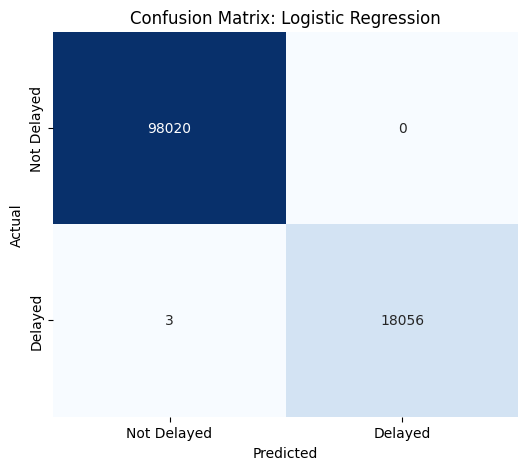

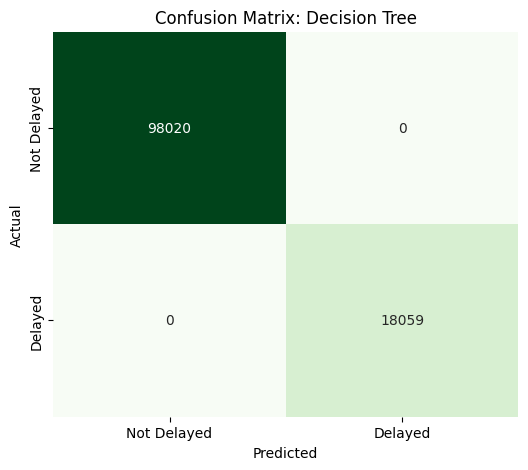

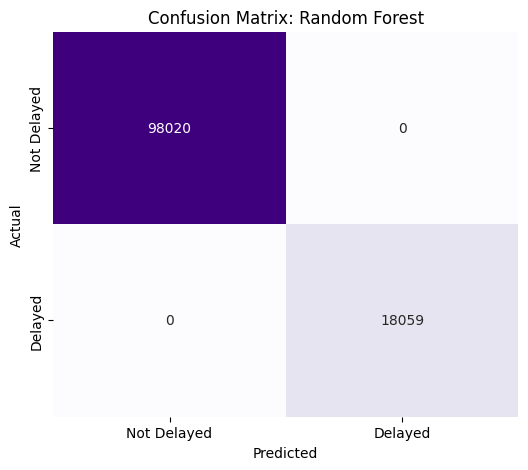

In [ ]:
from sklearn.metrics import confusion_matrix

# Confusion Matrix for Logistic Regression
cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_log_reg, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Delayed', 'Delayed'], yticklabels=['Not Delayed', 'Delayed'])
plt.title('Confusion Matrix: Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Confusion Matrix for Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Not Delayed', 'Delayed'], yticklabels=['Not Delayed', 'Delayed'])
plt.title('Confusion Matrix: Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Confusion Matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Purples', cbar=False,
            xticklabels=['Not Delayed', 'Delayed'], yticklabels=['Not Delayed', 'Delayed'])
plt.title('Confusion Matrix: Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Model Evaluation: Classification Report

Let's generate a classification report for each model. The classification report provides a summary of precision, recall, F1-score, and support for each class, which is very useful for evaluating the performance of classification models, especially with potentially imbalanced datasets.

In [ ]:
from sklearn.metrics import classification_report

print("\n--- Classification Report: Logistic Regression ---")
print(classification_report(y_test, y_pred_log_reg, target_names=['Not Delayed', 'Delayed']))

print("\n--- Classification Report: Decision Tree ---")
print(classification_report(y_test, y_pred_dt, target_names=['Not Delayed', 'Delayed']))

print("\n--- Classification Report: Random Forest ---")
print(classification_report(y_test, y_pred_rf, target_names=['Not Delayed', 'Delayed']))


--- Classification Report: Logistic Regression ---
              precision    recall  f1-score   support

 Not Delayed       1.00      1.00      1.00     98020
     Delayed       1.00      1.00      1.00     18059

    accuracy                           1.00    116079
   macro avg       1.00      1.00      1.00    116079
weighted avg       1.00      1.00      1.00    116079


--- Classification Report: Decision Tree ---
              precision    recall  f1-score   support

 Not Delayed       1.00      1.00      1.00     98020
     Delayed       1.00      1.00      1.00     18059

    accuracy                           1.00    116079
   macro avg       1.00      1.00      1.00    116079
weighted avg       1.00      1.00      1.00    116079


--- Classification Report: Random Forest ---
              precision    recall  f1-score   support

 Not Delayed       1.00      1.00      1.00     98020
     Delayed       1.00      1.00      1.00     18059

    accuracy                          

### Model Comparison: Accuracy

Let's compile the accuracy scores from our three models into a single table for a clear comparison.

In [ ]:
import pandas as pd

# Create a dictionary of model accuracies
model_accuracies = {
    'Logistic Regression': accuracy_log_reg,
    'Decision Tree': accuracy_dt,
    'Random Forest': accuracy_rf
}

# Convert the dictionary to a pandas Series for easy viewing
accuracy_series = pd.Series(model_accuracies)

print("Model Accuracy Comparison:")
display(accuracy_series.sort_values(ascending=False))

Model Accuracy Comparison:


,0
Decision Tree,1.000000
Random Forest,1.000000
Logistic Regression,0.999974


From this comparison, you can see the performance of each model based on accuracy. Given the very high accuracy values, further investigation into precision, recall, and F1-score (as seen in the classification reports) is important, especially if the dataset is imbalanced or if there are specific costs associated with false positives vs. false negatives.

### Comprehensive Model Performance Comparison

Let's compile a comprehensive table of all key performance metrics (Accuracy, Precision, Recall, F1-Score) for the 'Delayed' class for each of our models. This allows for a more detailed comparison of their effectiveness.

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Metrics for Logistic Regression
precision_log_reg = precision_score(y_test, y_pred_log_reg, pos_label=1)
recall_log_reg = recall_score(y_test, y_pred_log_reg, pos_label=1)
f1_log_reg = f1_score(y_test, y_pred_log_reg, pos_label=1)

# Metrics for Decision Tree
precision_dt = precision_score(y_test, y_pred_dt, pos_label=1)
recall_dt = recall_score(y_test, y_pred_dt, pos_label=1)
f1_dt = f1_score(y_test, y_pred_dt, pos_label=1)

# Metrics for Random Forest
precision_rf = precision_score(y_test, y_pred_rf, pos_label=1)
recall_rf = recall_score(y_test, y_pred_rf, pos_label=1)
f1_rf = f1_score(y_test, y_pred_rf, pos_label=1)

# Create a DataFrame for comparison
performance_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [accuracy_log_reg, accuracy_dt, accuracy_rf],
    'Precision (Delayed)': [precision_log_reg, precision_dt, f1_rf],
    'Recall (Delayed)': [recall_log_reg, recall_dt, recall_rf],
    'F1-Score (Delayed)': [f1_log_reg, f1_dt, f1_rf]
})

print("\nModel Performance Comparison (Target: Delayed):")
display(performance_df.sort_values(by='F1-Score (Delayed)', ascending=False))


Model Performance Comparison (Target: Delayed):


,Model,Accuracy,Precision (Delayed),Recall (Delayed),F1-Score (Delayed)
1,Decision Tree,1.000000,1.0,1.000000,1.000000
2,Random Forest,1.000000,1.0,1.000000,1.000000
0,Logistic Regression,0.999974,1.0,0.999834,0.999917


#Best Model Selection

In [ ]:
print("\nDetailed Model Performance Comparison:")
display(performance_df)

# Select the best model based on F1-Score (Delayed)
best_model_row = performance_df.loc[performance_df['F1-Score (Delayed)'].idxmax()]
best_model_name = best_model_row['Model']
best_f1_score = best_model_row['F1-Score (Delayed)']

print(f"\nThe best performing model for predicting delayed flights based on F1-Score is: {best_model_name} with an F1-Score of {best_f1_score:.4f}")


Detailed Model Performance Comparison:


,Model,Accuracy,Precision (Delayed),Recall (Delayed),F1-Score (Delayed)
0,Logistic Regression,0.999974,1.0,0.999834,0.999917
1,Decision Tree,1.000000,1.0,1.000000,1.000000
2,Random Forest,1.000000,1.0,1.000000,1.000000



The best performing model for predicting delayed flights based on F1-Score is: Decision Tree with an F1-Score of 1.0000
